# Mini-Project: Predicting Student Success (Pass/Fail)
**Dataset:** Portuguese Language – student-por.csv  
**University of Biskra – Machine Learning 1 – 2025/2026**
---

## Step 0 – Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import copy

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, learning_curve,
                                     StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1 – Data Loading & Initial Inspection (TP1)

In [2]:
df_original = pd.read_csv('student-por.csv', sep=';')
df = df_original.copy()
print(f"Shape: {df.shape}")
df.head()

Shape: (649, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,1


In [3]:
print("=== Dataset Info ===")
df.info()
print()
print("=== Descriptive Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    o

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009,0.845917
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656,0.361307
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000,1.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000,1.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000,1.000000


In [4]:
num_cols_all = df.select_dtypes(include='number').columns.tolist()
cat_cols_all = df.select_dtypes(exclude='number').columns.tolist()
print(f"Numerical   ({len(num_cols_all)}): {num_cols_all}")
print(f"Categorical ({len(cat_cols_all)}): {cat_cols_all}")

Numerical   (17): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'pass']
Categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## Step 2 – Exploratory Data Analysis & Visualisation (TP1 / Task 1)

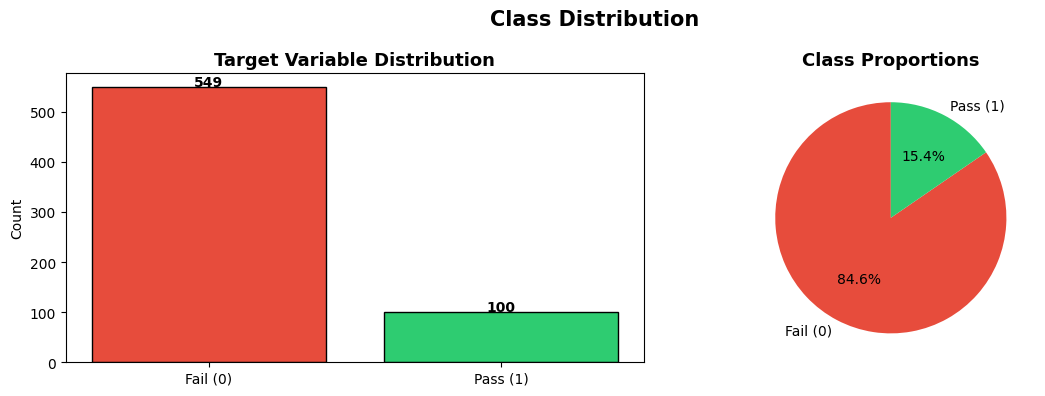

Pass: 549 (84.6%) | Fail: 100 (15.4%)
=> IMBALANCED dataset: ~84.6% Pass


In [5]:
# 2.1 Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['pass'].value_counts()
axes[0].bar(['Fail (0)','Pass (1)'], counts.values,
            color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Fail (0)','Pass (1)'],
            autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'], startangle=90)
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')
plt.suptitle('Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pass: {counts[1]} ({counts[1]/len(df)*100:.1f}%) | Fail: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print("=> IMBALANCED dataset: ~84.6% Pass")

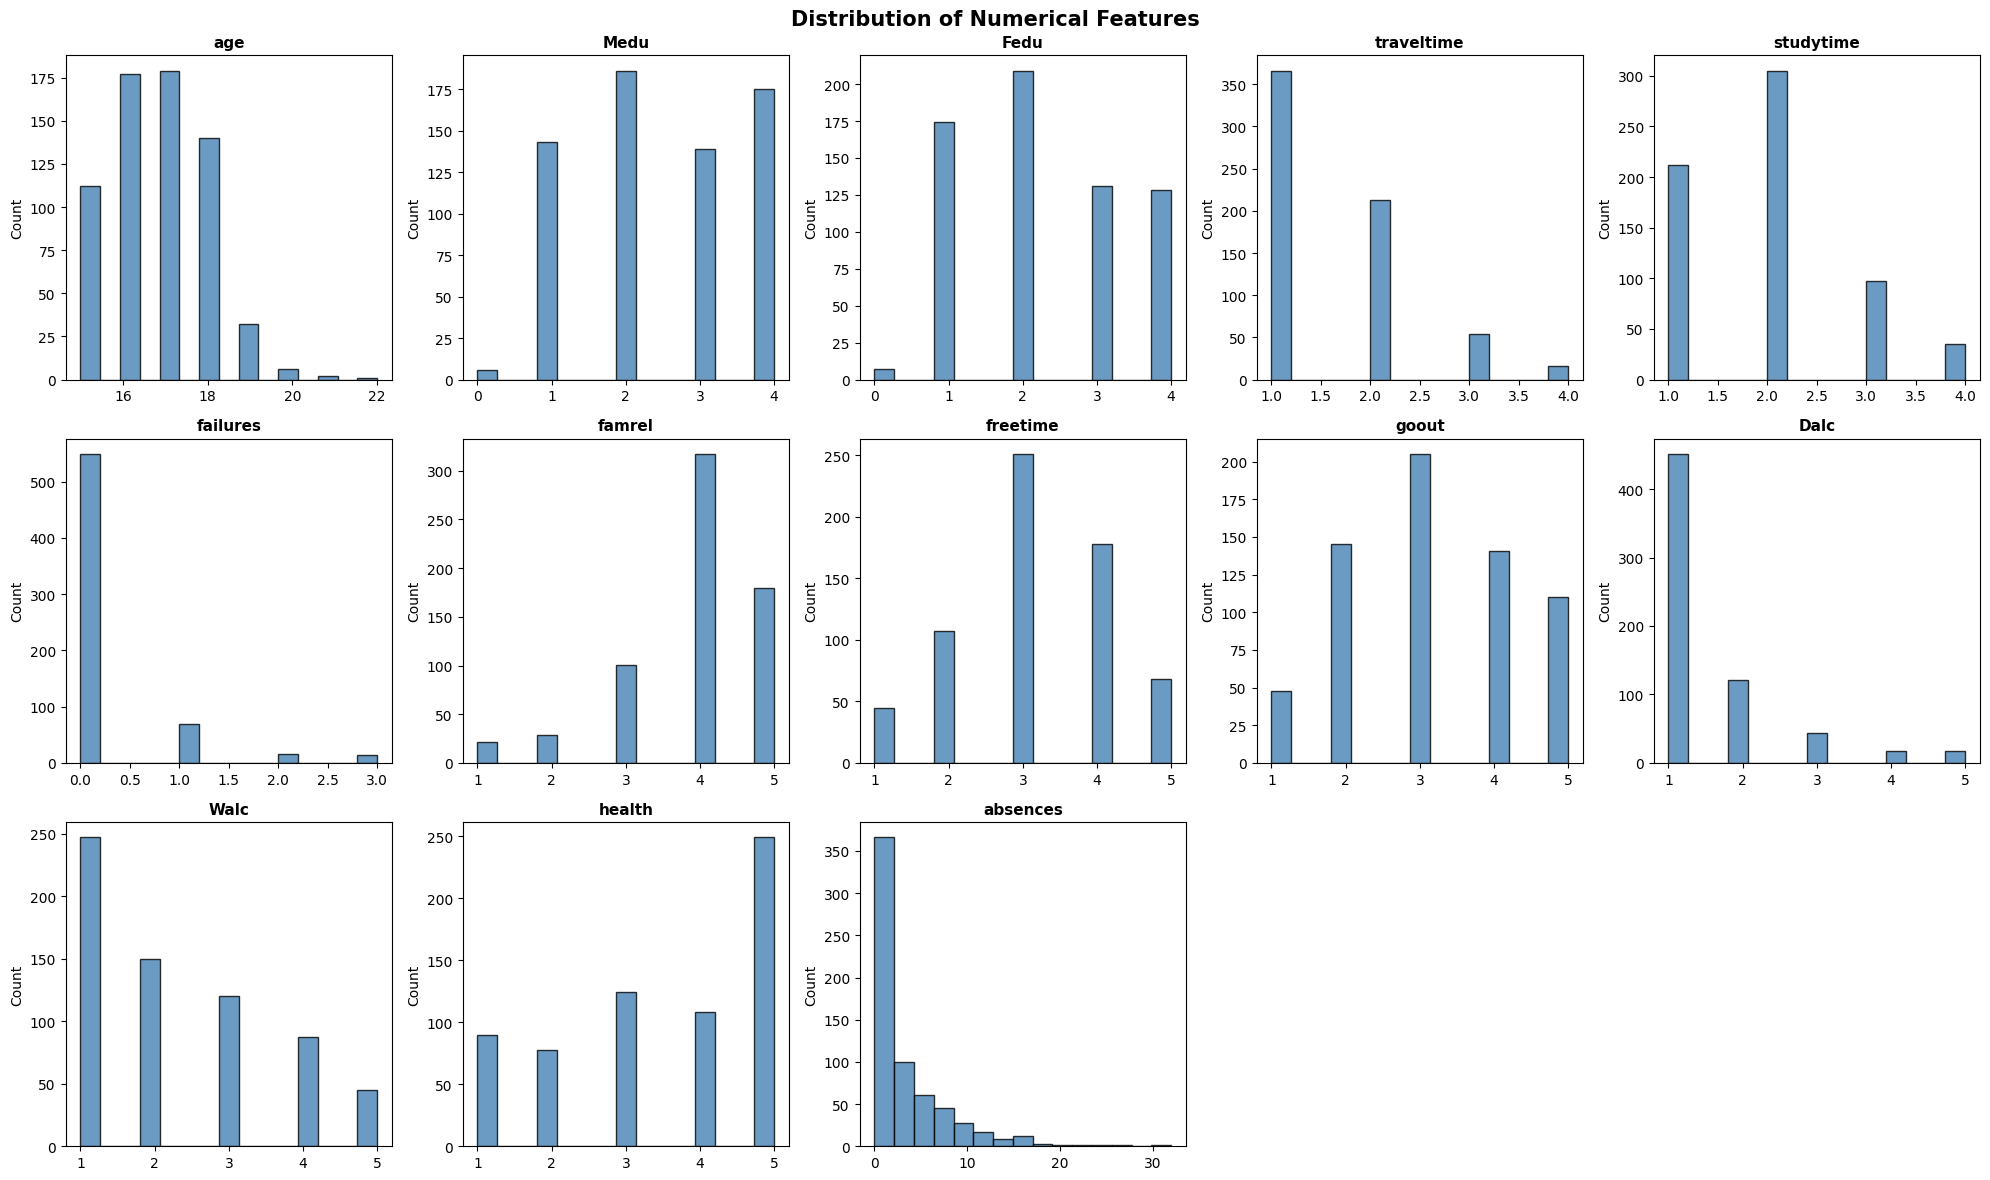

In [6]:
# 2.2 Numerical feature distributions
num_feat = ['age','Medu','Fedu','traveltime','studytime','failures',
            'famrel','freetime','goout','Dalc','Walc','health','absences']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(num_feat):
    axes[i].hist(df[col], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
for j in range(len(num_feat), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_num_dist.png', dpi=150, bbox_inches='tight')
plt.show()

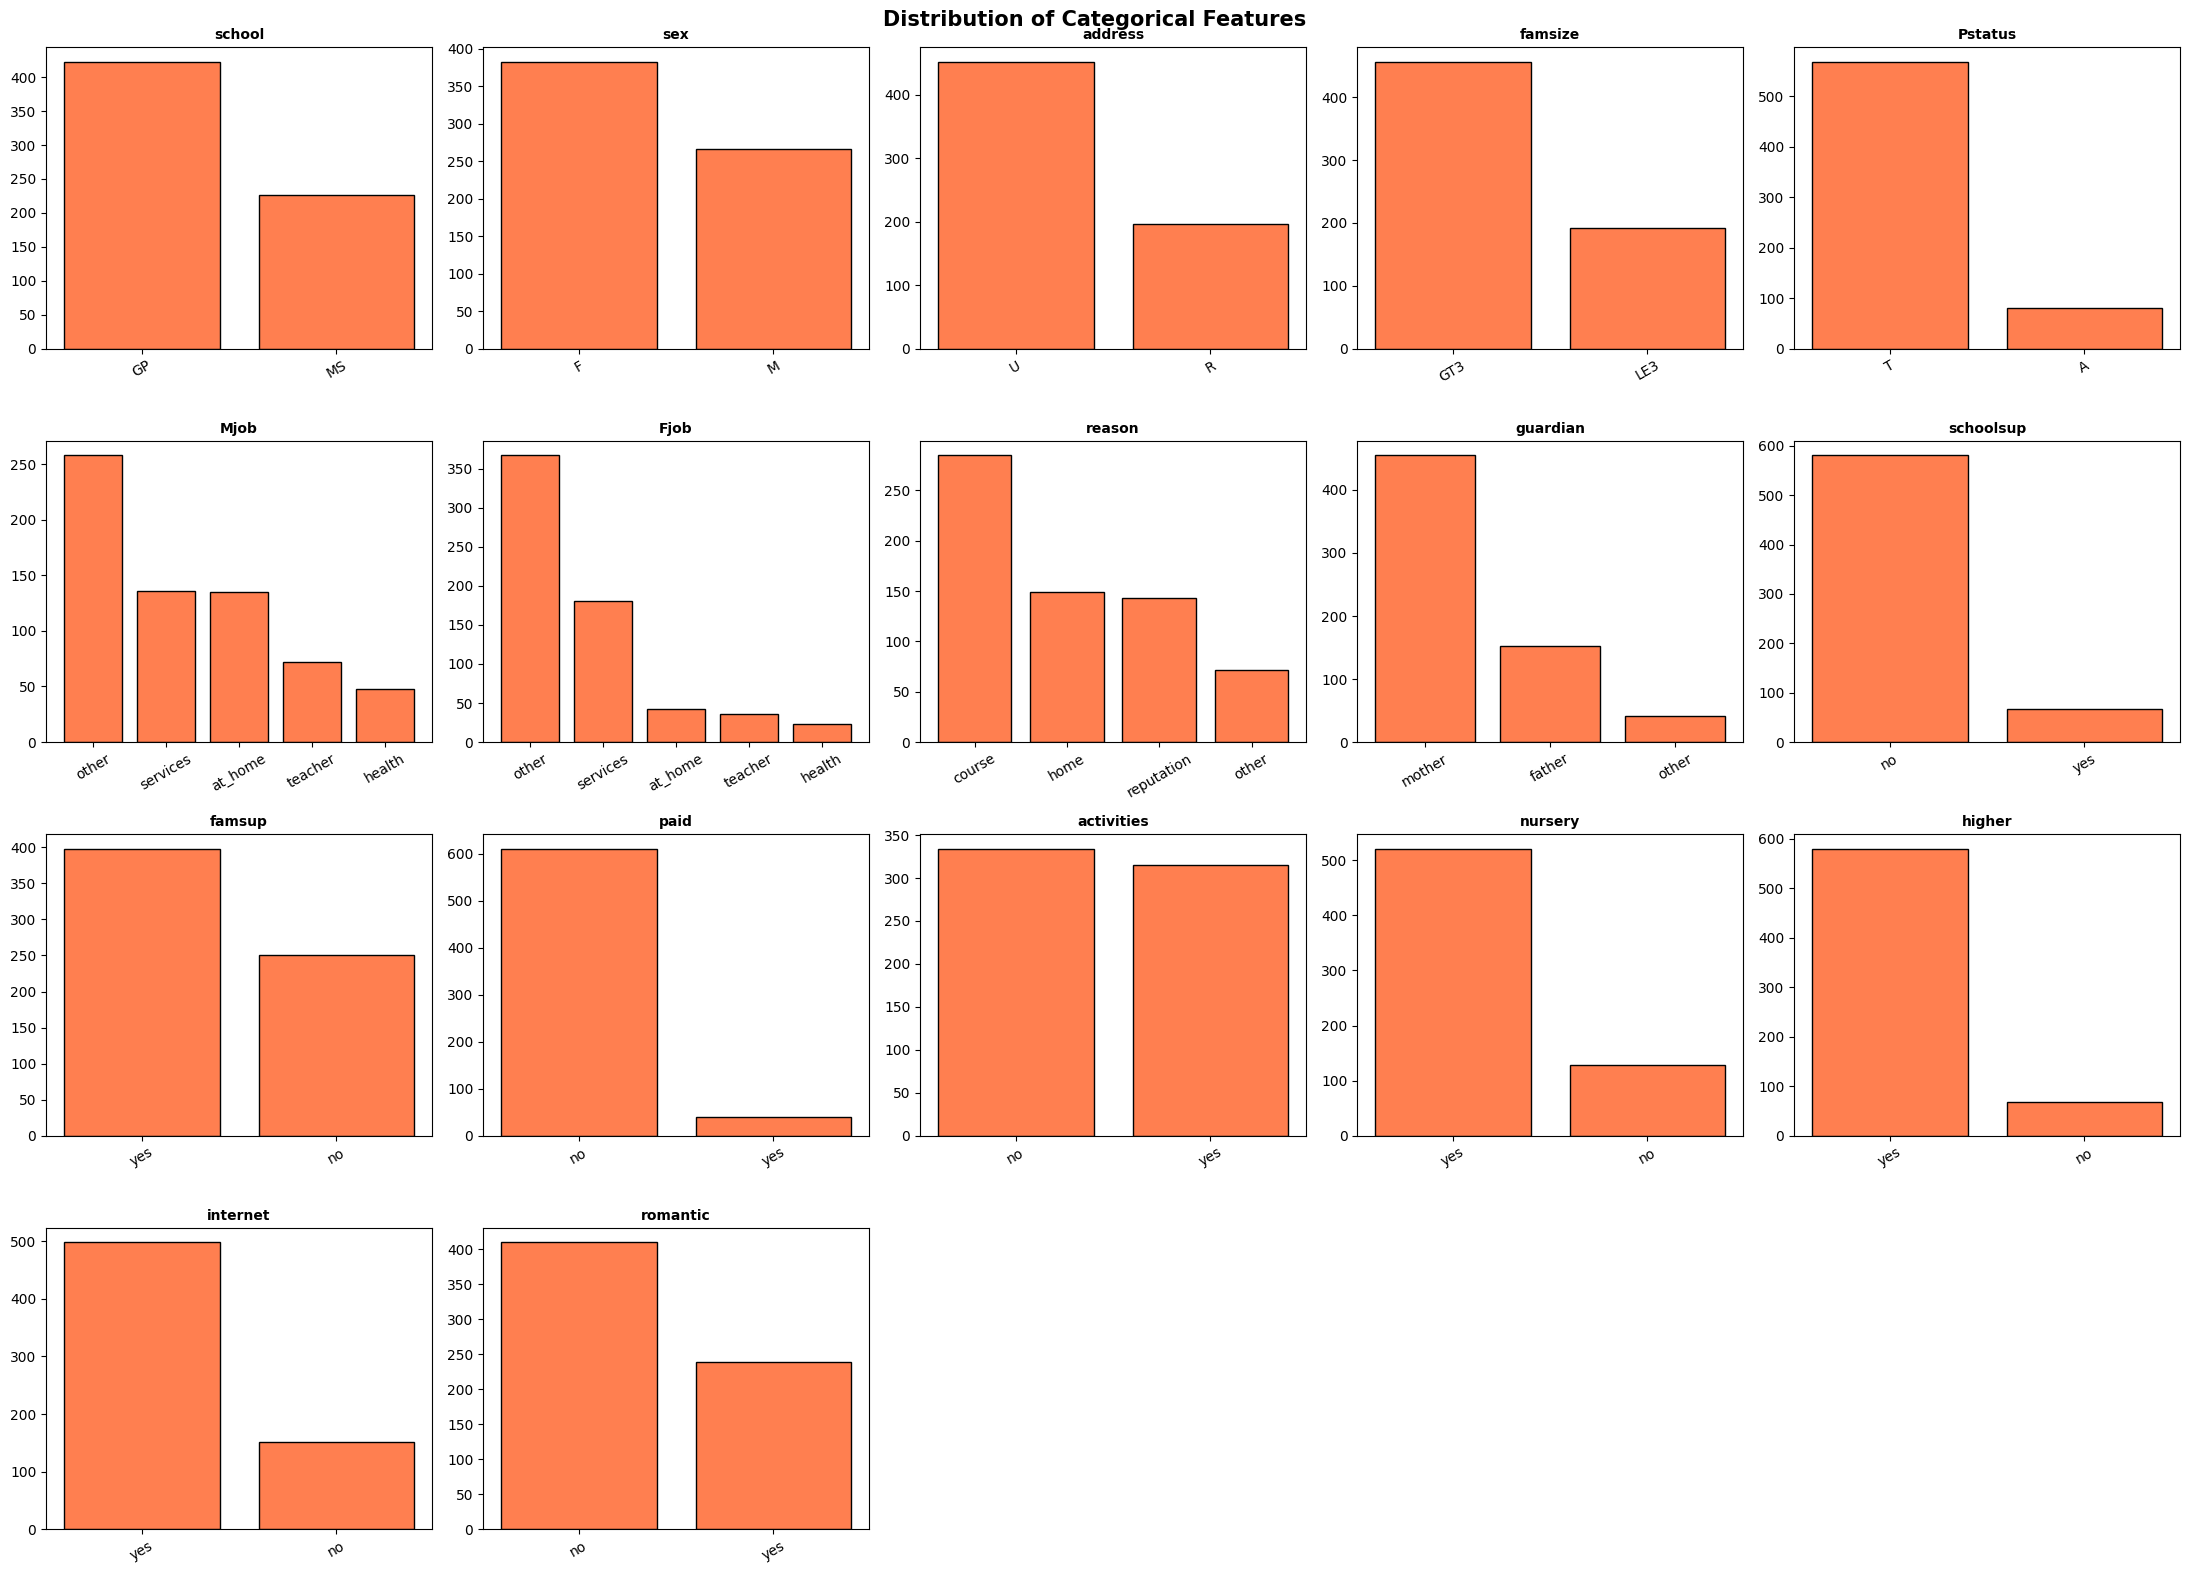

In [7]:
# 2.3 Categorical feature distributions
cat_feat = ['school','sex','address','famsize','Pstatus','Mjob','Fjob',
            'reason','guardian','schoolsup','famsup','paid','activities',
            'nursery','higher','internet','romantic']

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()
for i, col in enumerate(cat_feat):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='coral', edgecolor='black')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(cat_feat), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution of Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cat_dist.png', dpi=150, bbox_inches='tight')
plt.show()

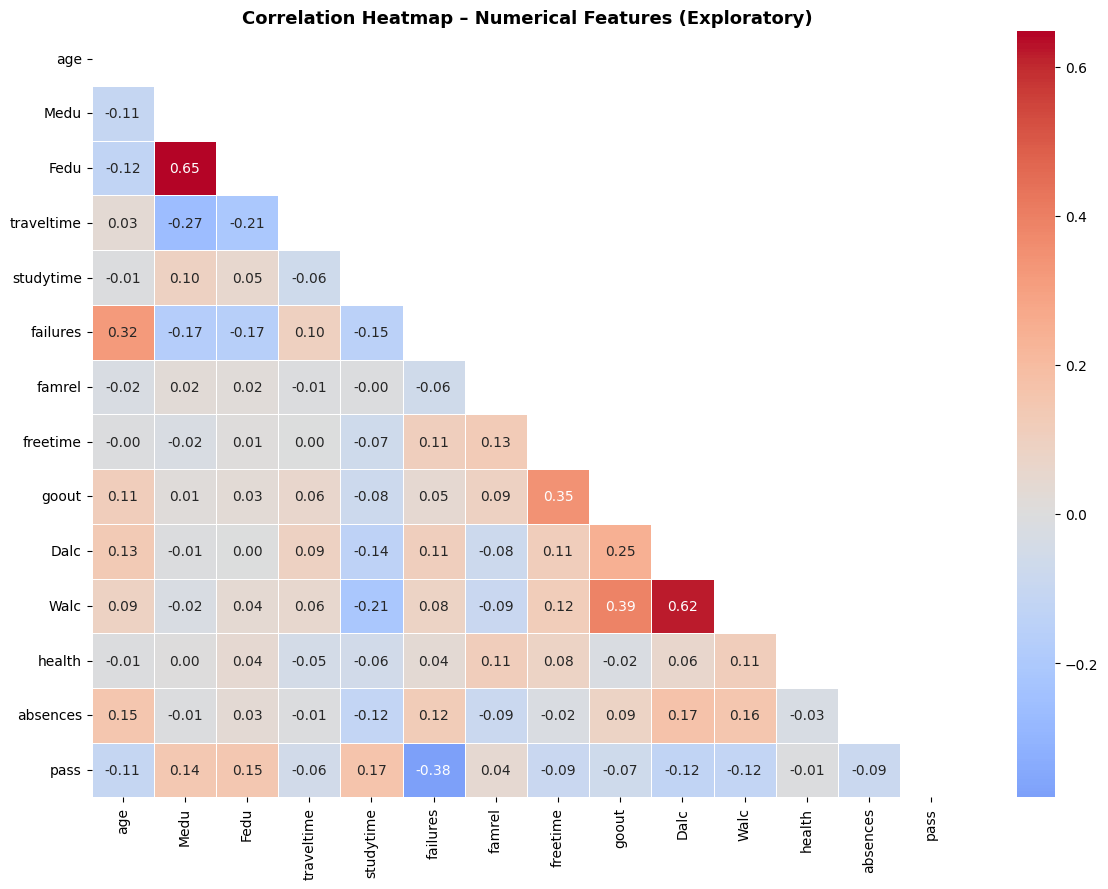

Top features correlated with 'pass':
failures     0.380237
studytime    0.165111
Fedu         0.146249
Medu         0.144803
Dalc         0.123627
Walc         0.116249
age          0.110722
freetime     0.093349
Name: pass, dtype: float64


In [8]:
# 2.4 Correlation heatmap (exploratory – full data before split)
plt.figure(figsize=(12, 9))
num_explore = df[num_feat + ['pass']].corr()
mask = np.triu(np.ones_like(num_explore, dtype=bool))
sns.heatmap(num_explore, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap – Numerical Features (Exploratory)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

corr_with_target = abs(num_explore['pass']).drop('pass').sort_values(ascending=False)
print("Top features correlated with 'pass':")
print(corr_with_target.head(8))

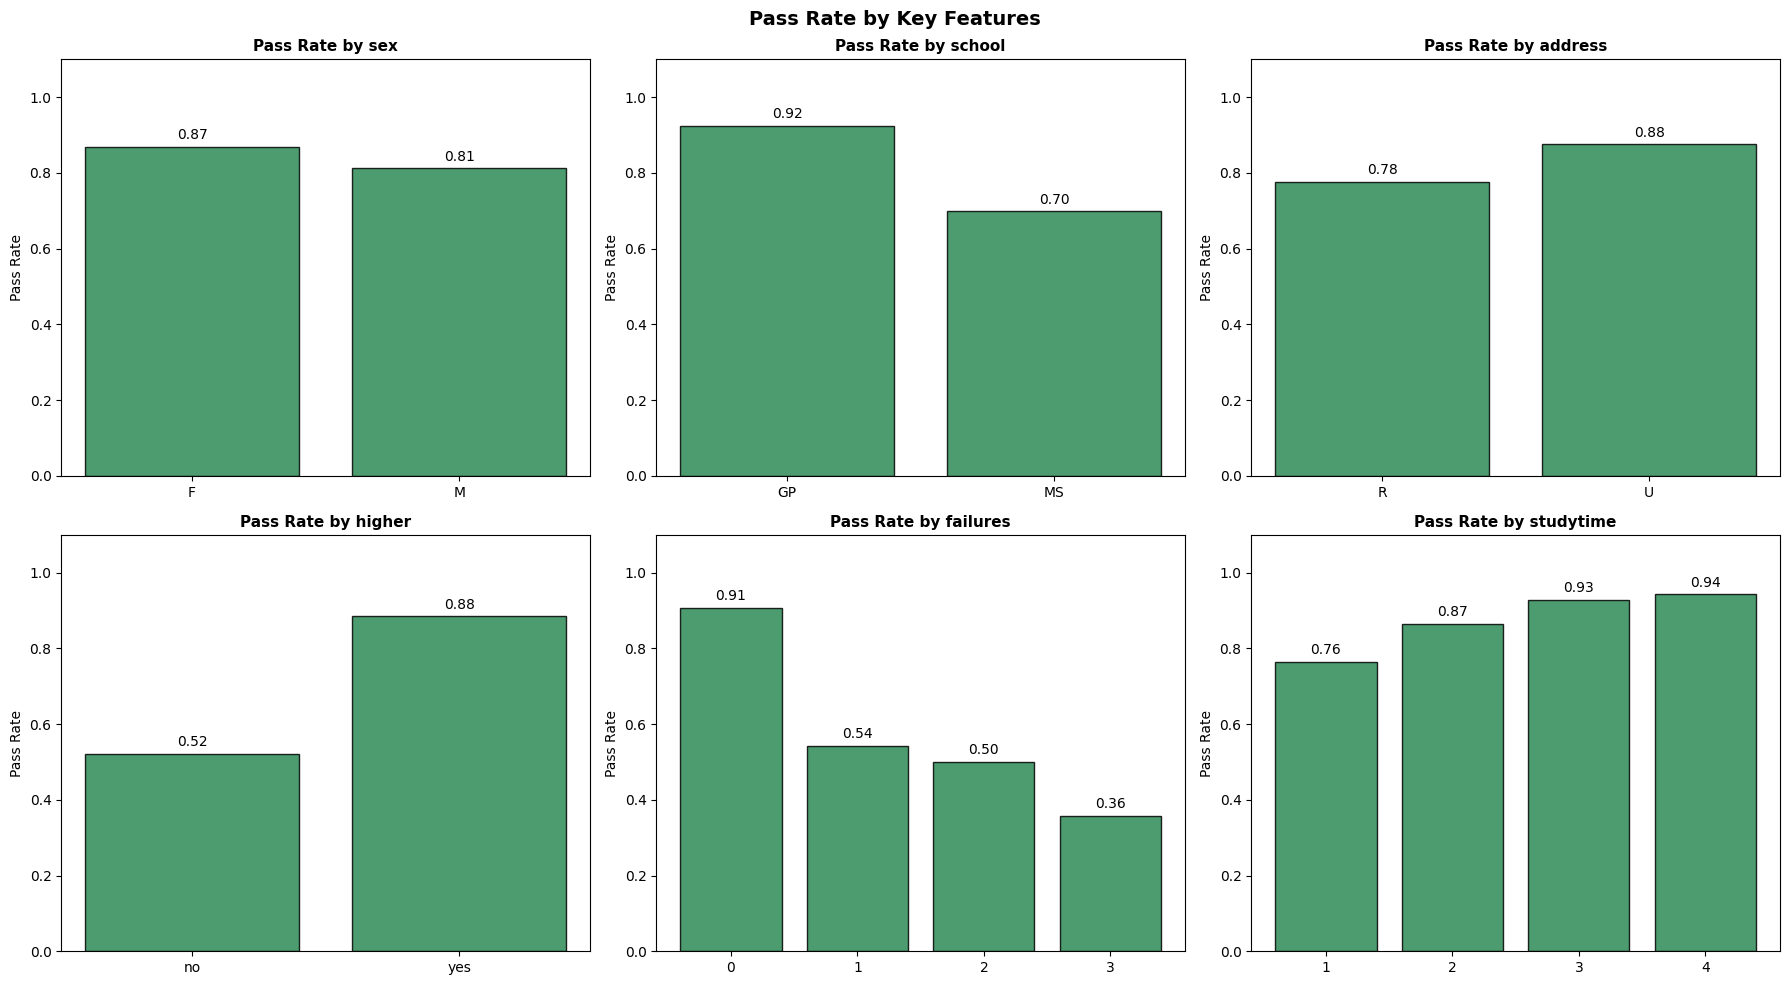

In [9]:
# 2.5 Pass rate by key features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(),
                   ['sex','school','address','higher','failures','studytime']):
    pr = df.groupby(col)['pass'].mean()
    ax.bar(pr.index.astype(str), pr.values, color='seagreen', edgecolor='black', alpha=0.85)
    ax.set_title(f'Pass Rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Pass Rate')
    ax.set_ylim(0, 1.1)
    for i, v in enumerate(pr.values):
        ax.text(i, v+0.02, f'{v:.2f}', ha='center')
plt.suptitle('Pass Rate by Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pass_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 – Data Preprocessing (TP2 / Task 2)

In [10]:
# 3.1 Missing values
missing = df.isnull().sum()
pct = (missing / len(df)) * 100
mv = pd.DataFrame({'Count': missing, 'Percentage (%)': pct})
mv = mv[mv['Count'] > 0]
if mv.empty:
    print("No missing values. Dataset is complete.")
else:
    print(mv)

No missing values. Dataset is complete.


In [11]:
# 3.2 Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Shape before: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after:  {df.shape}")

Duplicate rows: 0
Shape before: (649, 34)
Shape after:  (649, 34)


In [12]:
# 3.3 Drop G1, G2, G3 – direct data leakage (they directly determine 'pass')
df_clean = df.drop(columns=['G1', 'G2', 'G3'])
print(f"Dropped G1/G2/G3 (data leakage).")
print(f"Shape: {df_clean.shape}")

Dropped G1/G2/G3 (data leakage).
Shape: (649, 31)


In [13]:
# 3.4 Outlier detection & capping (IQR method, all numerical features)
num_features = ['age','traveltime','studytime','failures',
                'famrel','freetime','goout','Dalc','Walc','health','absences']

print("=== Outliers (IQR Method) ===")
df_before = df_clean.copy()
for col in num_features:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    if n > 0:
        df_clean[col] = df_clean[col].clip(lo, hi)
        print(f"  {col:12s}: {n:3d} outliers capped to [{lo:.1f}, {hi:.1f}]")

print("\nJustification: Capping preserves all rows while reducing extreme influence.")

=== Outliers (IQR Method) ===
  age         :   1 outliers capped to [13.0, 21.0]
  traveltime  :  16 outliers capped to [-0.5, 3.5]
  studytime   :  35 outliers capped to [-0.5, 3.5]
  failures    : 100 outliers capped to [0.0, 0.0]
  famrel      :  51 outliers capped to [2.5, 6.5]
  freetime    :  45 outliers capped to [1.5, 5.5]
  Dalc        :  34 outliers capped to [-0.5, 3.5]
  absences    :  21 outliers capped to [-9.0, 15.0]

Justification: Capping preserves all rows while reducing extreme influence.


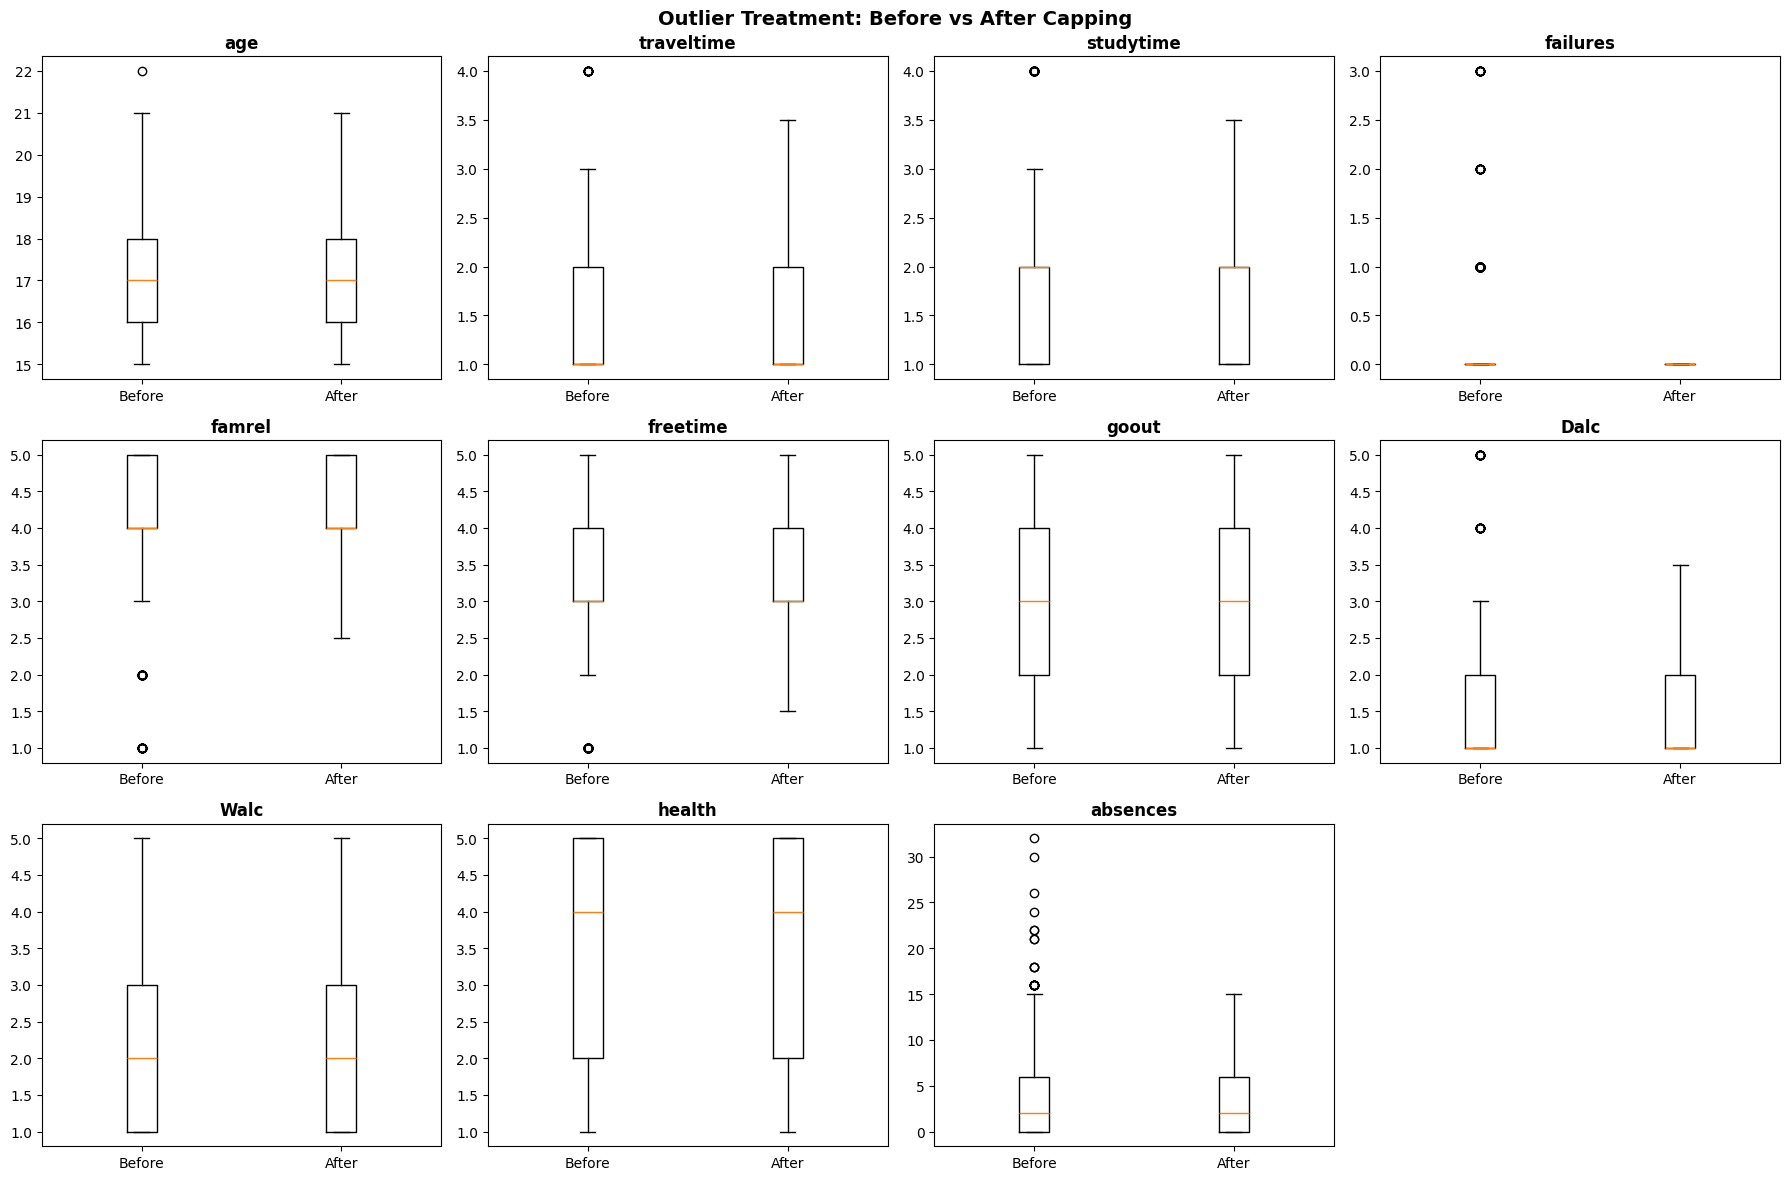

In [14]:
# Boxplots: before vs after outlier treatment
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].boxplot([df_before[col], df_clean[col]], labels=['Before','After'])
    axes[i].set_title(col, fontweight='bold')
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Outlier Treatment: Before vs After Capping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# 3.5 Separate features and target
X = df_clean.drop(columns=['pass'])
y = df_clean['pass']
print(f"X: {X.shape}  |  y: {y.shape}  |  Classes: {sorted(y.unique())}") 

X: (649, 30)  |  y: (649,)  |  Classes: [np.int64(0), np.int64(1)]


In [16]:
# 3.6 Stratified Train/Test split 80/20 – BEFORE encoding/scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print("Train class dist:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  class dist:", y_test.value_counts(normalize=True).round(3).to_dict())

X_train: (519, 30)  |  X_test: (130, 30)
Train class dist: {1: 0.846, 0: 0.154}
Test  class dist: {1: 0.846, 0: 0.154}


In [17]:
# 3.7 Identify column types
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Numerical   ({len(num_cols)}): {num_cols}")

Categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical   (13): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [18]:
# 3.8 One-Hot Encoding – fit on X_train only, then apply to both
# Justification: avoids artificial ordinal relationships for nominal variables.
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0)
print(f"After encoding → train: {X_train_enc.shape} | test: {X_test_enc.shape}")

After encoding → train: (519, 39) | test: (130, 39)


In [19]:
# 3.9 StandardScaler – fit on X_train only
# Justification: more robust to remaining skewness than MinMaxScaler.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc), columns=X_train_enc.columns)
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test_enc),     columns=X_test_enc.columns)
print("StandardScaler applied (fit on train only).")

StandardScaler applied (fit on train only).


Before SMOTE: Counter({1: 439, 0: 80})
After  SMOTE: Counter({1: 439, 0: 439})


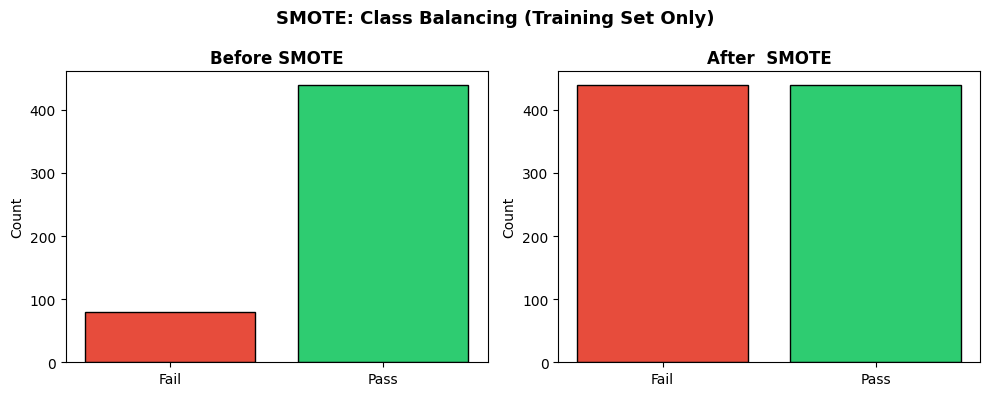

In [20]:
# 3.10 SMOTE – only on training set
print(f"Before SMOTE: {Counter(y_train)}")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f"After  SMOTE: {Counter(y_train_bal)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cnt, title) in zip(axes, [
        (Counter(y_train),     "Before SMOTE"),
        (Counter(y_train_bal), "After  SMOTE")]):
    ax.bar(['Fail','Pass'], [cnt[0], cnt[1]],
           color=['#e74c3c','#2ecc71'], edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('SMOTE: Class Balancing (Training Set Only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 – Find Best Hyperparameters via Complexity Curves (TP3 Ex9)

> ⚠️ Done **before** defining the final models so we can plug in the optimal values directly.

Best max_depth for Decision Tree: 5  (CV F1=0.8959)


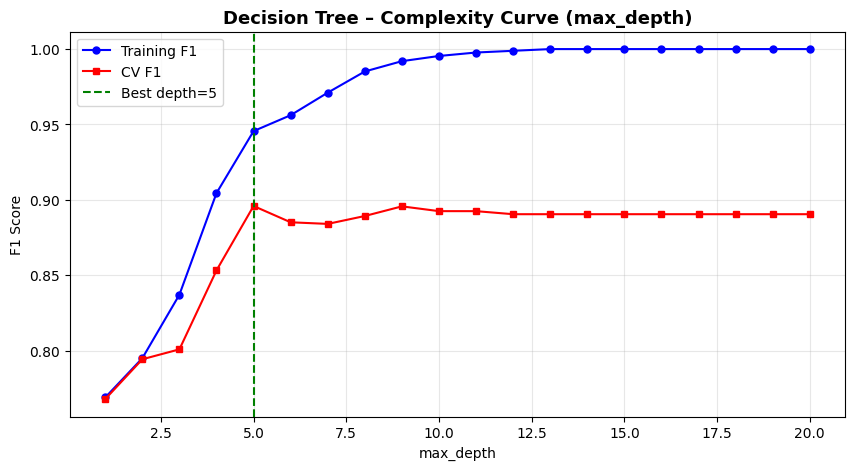

In [21]:
# 4.1 Decision Tree – find best max_depth
depths = range(1, 21)
dt_train_accs, dt_cv_accs = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    cv_sc = cross_val_score(clf, X_train_bal, y_train_bal,
                             cv=5, scoring='f1', n_jobs=-1)
    clf.fit(X_train_bal, y_train_bal)
    dt_train_accs.append(f1_score(y_train_bal, clf.predict(X_train_bal)))
    dt_cv_accs.append(cv_sc.mean())

best_depth = list(depths)[np.argmax(dt_cv_accs)]
print(f"Best max_depth for Decision Tree: {best_depth}  (CV F1={max(dt_cv_accs):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(depths, dt_train_accs, 'b-o', label='Training F1', markersize=5)
plt.plot(depths, dt_cv_accs,   'r-s', label='CV F1',       markersize=5)
plt.axvline(best_depth, color='green', linestyle='--', label=f'Best depth={best_depth}')
plt.title('Decision Tree – Complexity Curve (max_depth)', fontsize=13, fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('F1 Score')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('fig_dt_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

Best n_neighbors for KNN: 1  (CV F1=0.8649)


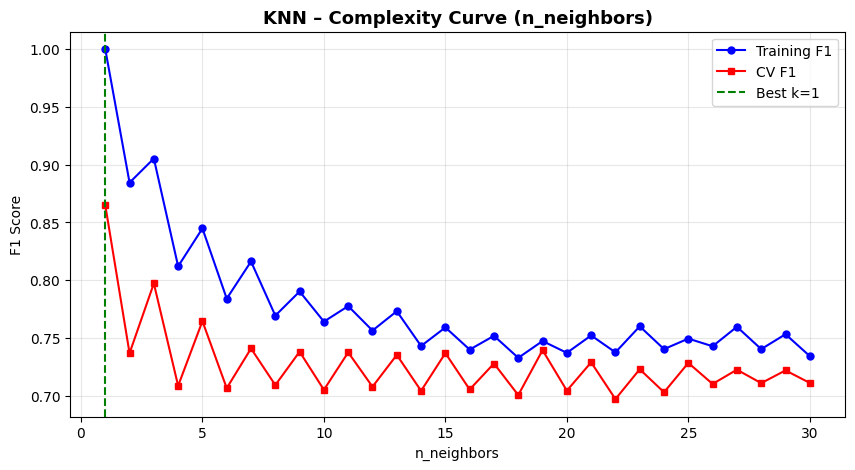

In [22]:
# 4.2 KNN – find best n_neighbors
k_range = range(1, 31)
knn_train_accs, knn_cv_accs = [], []

for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    cv_sc = cross_val_score(clf, X_train_bal, y_train_bal,
                             cv=5, scoring='f1', n_jobs=-1)
    clf.fit(X_train_bal, y_train_bal)
    knn_train_accs.append(f1_score(y_train_bal, clf.predict(X_train_bal)))
    knn_cv_accs.append(cv_sc.mean())

best_k = list(k_range)[np.argmax(knn_cv_accs)]
print(f"Best n_neighbors for KNN: {best_k}  (CV F1={max(knn_cv_accs):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(k_range, knn_train_accs, 'b-o', label='Training F1', markersize=5)
plt.plot(k_range, knn_cv_accs,   'r-s', label='CV F1',       markersize=5)
plt.axvline(best_k, color='green', linestyle='--', label=f'Best k={best_k}')
plt.title('KNN – Complexity Curve (n_neighbors)', fontsize=13, fontweight='bold')
plt.xlabel('n_neighbors')
plt.ylabel('F1 Score')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('fig_knn_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 – Model Definitions with Optimal Parameters

Now we use:
- **LR** → `class_weight='balanced'` (handles imbalance even after SMOTE)
- **DT** → `max_depth=best_depth` (from complexity curve Step 4.1)
- **KNN** → `n_neighbors=best_k` (from complexity curve Step 4.2)
- **RF** → defaults (will be tuned later with GridSearch)

In [23]:
# Models using best hyperparameters found above
models_def = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced'),          # ← handles imbalance
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=best_depth),             # ← from complexity curve
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100),                 # ← will be tuned with GridSearch
    'KNN': KNeighborsClassifier(
        n_neighbors=best_k),               # ← from complexity curve
}

print("Models ready with optimised parameters:")
for name, clf in models_def.items():
    print(f"  {name}: {clf}")

Models ready with optimised parameters:
  Logistic Regression: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
  Decision Tree: DecisionTreeClassifier(max_depth=5, random_state=42)
  Random Forest: RandomForestClassifier(random_state=42)
  KNN: KNeighborsClassifier(n_neighbors=1)


## Step 6 – Baseline: Raw (Unpreprocessed) Data (Task 4)

In [24]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    proba  = (model.predict_proba(X_te)[:,1]
              if hasattr(model,'predict_proba') else y_pred)
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred, zero_division=0),
        'F1':        f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_te, proba),
        '_model':    model,
        '_y_pred':   y_pred,
    }

In [25]:
# Raw data: simple Label Encoding only
X_raw = X.copy()
le = LabelEncoder()
for col in cat_cols:
    X_raw[col] = le.fit_transform(X_raw[col])

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

raw_results = [evaluate_model(name, copy.deepcopy(clf),
                               X_train_raw, y_train_raw,
                               X_test_raw,  y_test_raw)
               for name, clf in models_def.items()]

raw_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                        for r in raw_results]).set_index('Model').round(4)
print("=== RAW DATA PERFORMANCE ===")
print(raw_df)

=== RAW DATA PERFORMANCE ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.6462     0.8902  0.6636  0.7604   0.6355
Decision Tree          0.7846     0.8661  0.8818  0.8739   0.6207
Random Forest          0.8385     0.8560  0.9727  0.9106   0.6300
KNN                    0.7769     0.8649  0.8727  0.8688   0.5614


## Step 7 – Model Training & Evaluation on Preprocessed Data (Task 3)

In [26]:
proc_results = [evaluate_model(name, copy.deepcopy(clf),
                                X_train_bal, y_train_bal,
                                X_test_scaled, y_test)
                for name, clf in models_def.items()]

proc_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                         for r in proc_results]).set_index('Model').round(4)
print("=== PREPROCESSED DATA PERFORMANCE ===")
print(proc_df)

=== PREPROCESSED DATA PERFORMANCE ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.6769     0.8864  0.7091  0.7879   0.5759
Decision Tree          0.7615     0.8559  0.8636  0.8597   0.5959
Random Forest          0.7462     0.8407  0.8636  0.8520   0.5955
KNN                    0.6769     0.8617  0.7364  0.7941   0.5432


In [27]:
# Classification reports
for res in proc_results:
    print(f"\n{'='*50}")
    print(f"  {res['Model']}")
    print('='*50)
    print(classification_report(y_test, res['_y_pred'],
                                 target_names=['Fail (0)','Pass (1)']))


  Logistic Regression
              precision    recall  f1-score   support

    Fail (0)       0.24      0.50      0.32        20
    Pass (1)       0.89      0.71      0.79       110

    accuracy                           0.68       130
   macro avg       0.56      0.60      0.56       130
weighted avg       0.79      0.68      0.72       130


  Decision Tree
              precision    recall  f1-score   support

    Fail (0)       0.21      0.20      0.21        20
    Pass (1)       0.86      0.86      0.86       110

    accuracy                           0.76       130
   macro avg       0.53      0.53      0.53       130
weighted avg       0.76      0.76      0.76       130


  Random Forest
              precision    recall  f1-score   support

    Fail (0)       0.12      0.10      0.11        20
    Pass (1)       0.84      0.86      0.85       110

    accuracy                           0.75       130
   macro avg       0.48      0.48      0.48       130
weighted avg     

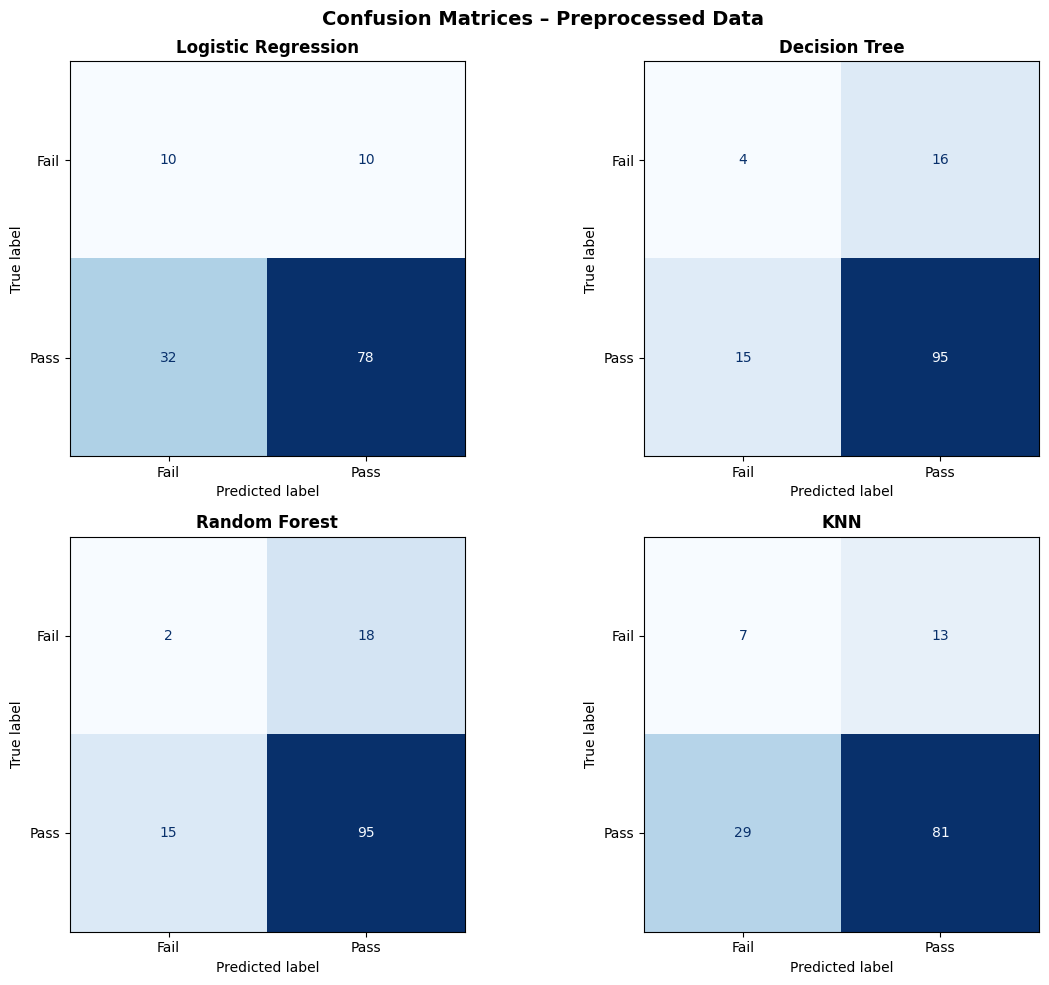

In [28]:
# Confusion matrices – all 4 models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, res in zip(axes.flatten(), proc_results):
    cm = confusion_matrix(y_test, res['_y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['Model'], fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrices – Preprocessed Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 – Cross-Validation (TP3 Ex8 / Task 3)

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("=== 5-Fold Stratified CV (on training set only) ===\n")

cv_rows = []
for name, clf in models_def.items():
    scores = cross_val_score(copy.deepcopy(clf),
                              X_train_bal, y_train_bal,
                              cv=skf, scoring='f1', n_jobs=-1)
    cv_rows.append({
        'Model':      name,
        'CV F1 Mean': round(scores.mean(), 4),
        'CV F1 Std':  round(scores.std(),  4),
        'Test F1':    proc_df.loc[name, 'F1']
    })
    print(f"{name:22s} | CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

print()
print(pd.DataFrame(cv_rows).set_index('Model'))

=== 5-Fold Stratified CV (on training set only) ===

Logistic Regression    | CV F1: 0.8507 ± 0.0104
Decision Tree          | CV F1: 0.8764 ± 0.0269
Random Forest          | CV F1: 0.9316 ± 0.0130
KNN                    | CV F1: 0.8667 ± 0.0222

                     CV F1 Mean  CV F1 Std  Test F1
Model                                              
Logistic Regression      0.8507     0.0104   0.7879
Decision Tree            0.8764     0.0269   0.8597
Random Forest            0.9316     0.0130   0.8520
KNN                      0.8667     0.0222   0.7941


## Step 9 – Learning Curve (Random Forest)

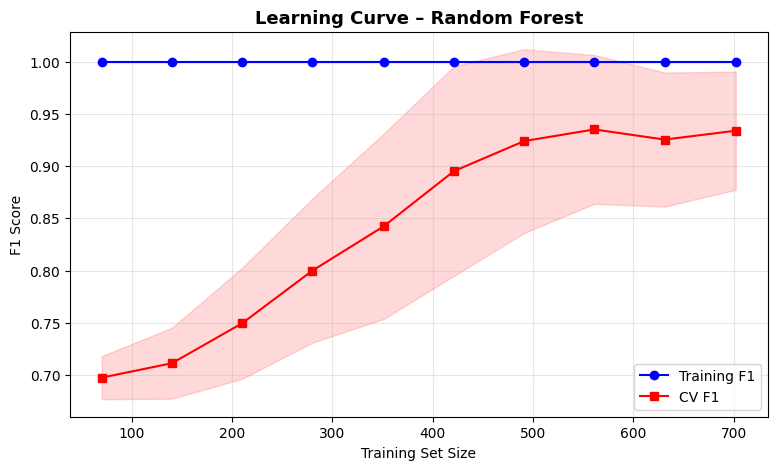

In [30]:
rf_lc = RandomForestClassifier(n_estimators=100, random_state=42)
train_sizes, train_sc, val_sc = learning_curve(
    rf_lc, X_train_bal, y_train_bal,
    cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_sc.mean(1), 'b-o', label='Training F1')
plt.fill_between(train_sizes,
                  train_sc.mean(1)-train_sc.std(1),
                  train_sc.mean(1)+train_sc.std(1), alpha=0.15, color='blue')
plt.plot(train_sizes, val_sc.mean(1), 'r-s', label='CV F1')
plt.fill_between(train_sizes,
                  val_sc.mean(1)-val_sc.std(1),
                  val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='red')
plt.title('Learning Curve – Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Score')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig('fig_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 – Hyperparameter Tuning with GridSearchCV (TP3 Ex10 / Task 3)

In [31]:
# Before tuning – base RF evaluated on test set
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_bal, y_train_bal)
base_pred  = rf_base.predict(X_test_scaled)
base_proba = rf_base.predict_proba(X_test_scaled)[:,1]
print("=== Before Tuning (Base RF) ===")
print(f"  Accuracy: {accuracy_score(y_test, base_pred):.4f}")
print(f"  F1      : {f1_score(y_test, base_pred):.4f}")
print(f"  ROC-AUC : {roc_auc_score(y_test, base_proba):.4f}")

=== Before Tuning (Base RF) ===
  Accuracy: 0.7462
  F1      : 0.8520
  ROC-AUC : 0.5955


In [32]:
# GridSearchCV – scoring='f1' (correct for imbalanced)
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2'],
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_search.fit(X_train_bal, y_train_bal)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1     : {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1     : 0.9446


=== After Tuning (Best RF) ===
  Accuracy: 0.7769
  F1      : 0.8722
  ROC-AUC : 0.6032

          Before Tuning  After Tuning
Metric                               
Accuracy         0.7462        0.7769
F1-Score         0.8520        0.8722
ROC-AUC          0.5955        0.6032


<Figure size 500x400 with 0 Axes>

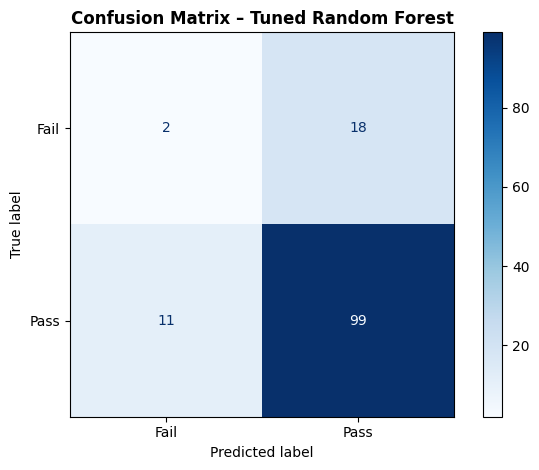

In [33]:
# After tuning
best_rf     = grid_search.best_estimator_
tuned_pred  = best_rf.predict(X_test_scaled)
tuned_proba = best_rf.predict_proba(X_test_scaled)[:,1]

print("=== After Tuning (Best RF) ===")
print(f"  Accuracy: {accuracy_score(y_test, tuned_pred):.4f}")
print(f"  F1      : {f1_score(y_test, tuned_pred):.4f}")
print(f"  ROC-AUC : {roc_auc_score(y_test, tuned_proba):.4f}")

# Before vs After table
tuning_cmp = pd.DataFrame({
    'Metric':        ['Accuracy','F1-Score','ROC-AUC'],
    'Before Tuning': [accuracy_score(y_test, base_pred),
                      f1_score(y_test, base_pred),
                      roc_auc_score(y_test, base_proba)],
    'After Tuning':  [accuracy_score(y_test, tuned_pred),
                      f1_score(y_test, tuned_pred),
                      roc_auc_score(y_test, tuned_proba)],
}).set_index('Metric').round(4)
print()
print(tuning_cmp)

# Confusion matrix – tuned RF
plt.figure(figsize=(5,4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, tuned_pred),
    display_labels=['Fail','Pass']).plot(cmap='Blues')
plt.title('Confusion Matrix – Tuned Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cm_tuned_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 – Comparative Analysis: Raw vs Preprocessed (Task 4)

In [34]:
metrics_keys = ['Accuracy','Precision','Recall','F1','ROC-AUC']
rows = []
for rr, pr in zip(raw_results, proc_results):
    for m in metrics_keys:
        rows.append({'Model': rr['Model'], 'Metric': m,
                     'Raw': round(rr[m],4), 'Preprocessed+SMOTE': round(pr[m],4),
                     'Δ': round(pr[m]-rr[m],4)})
cmp_df = pd.DataFrame(rows)
print("=== Raw vs Preprocessed Comparison ===")
print(cmp_df.to_string(index=False))

=== Raw vs Preprocessed Comparison ===
              Model    Metric    Raw  Preprocessed+SMOTE       Δ
Logistic Regression  Accuracy 0.6462              0.6769  0.0308
Logistic Regression Precision 0.8902              0.8864 -0.0039
Logistic Regression    Recall 0.6636              0.7091  0.0455
Logistic Regression        F1 0.7604              0.7879  0.0275
Logistic Regression   ROC-AUC 0.6355              0.5759 -0.0595
      Decision Tree  Accuracy 0.7846              0.7615 -0.0231
      Decision Tree Precision 0.8661              0.8559 -0.0102
      Decision Tree    Recall 0.8818              0.8636 -0.0182
      Decision Tree        F1 0.8739              0.8597 -0.0141
      Decision Tree   ROC-AUC 0.6207              0.5959 -0.0248
      Random Forest  Accuracy 0.8385              0.7462 -0.0923
      Random Forest Precision 0.8560              0.8407 -0.0153
      Random Forest    Recall 0.9727              0.8636 -0.1091
      Random Forest        F1 0.9106              0

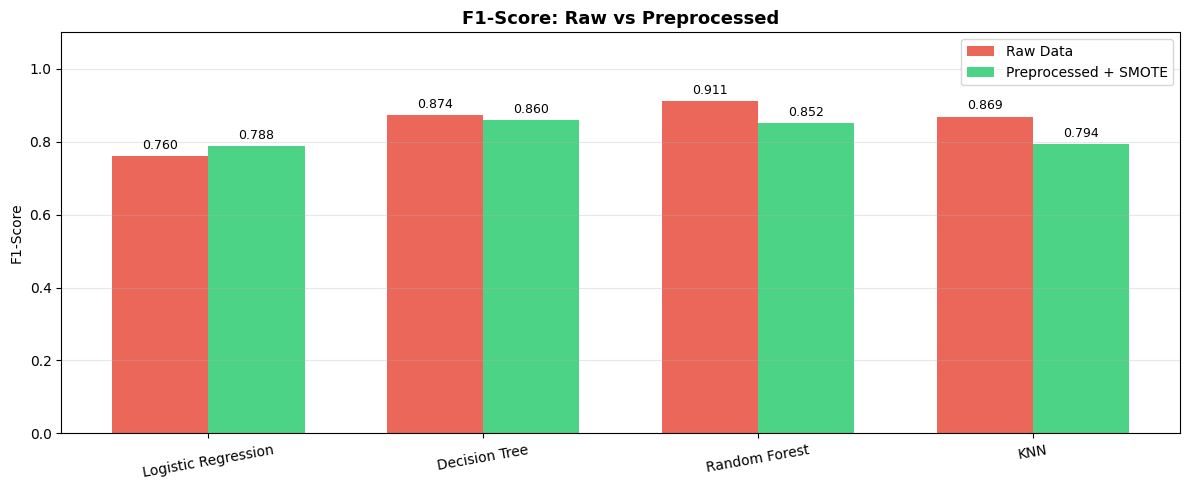

In [35]:
# F1 bar chart – visual comparison
f1_raw  = [r['F1'] for r in raw_results]
f1_proc = [r['F1'] for r in proc_results]
names   = [r['Model'] for r in raw_results]
x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x-w/2, f1_raw,  w, label='Raw Data',             color='#e74c3c', alpha=0.85)
b2 = ax.bar(x+w/2, f1_proc, w, label='Preprocessed + SMOTE', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=10)
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.1)
ax.set_title('F1-Score: Raw vs Preprocessed', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('fig_raw_vs_proc.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 – Correlation Analysis on Training Set (TP3 Ex4)

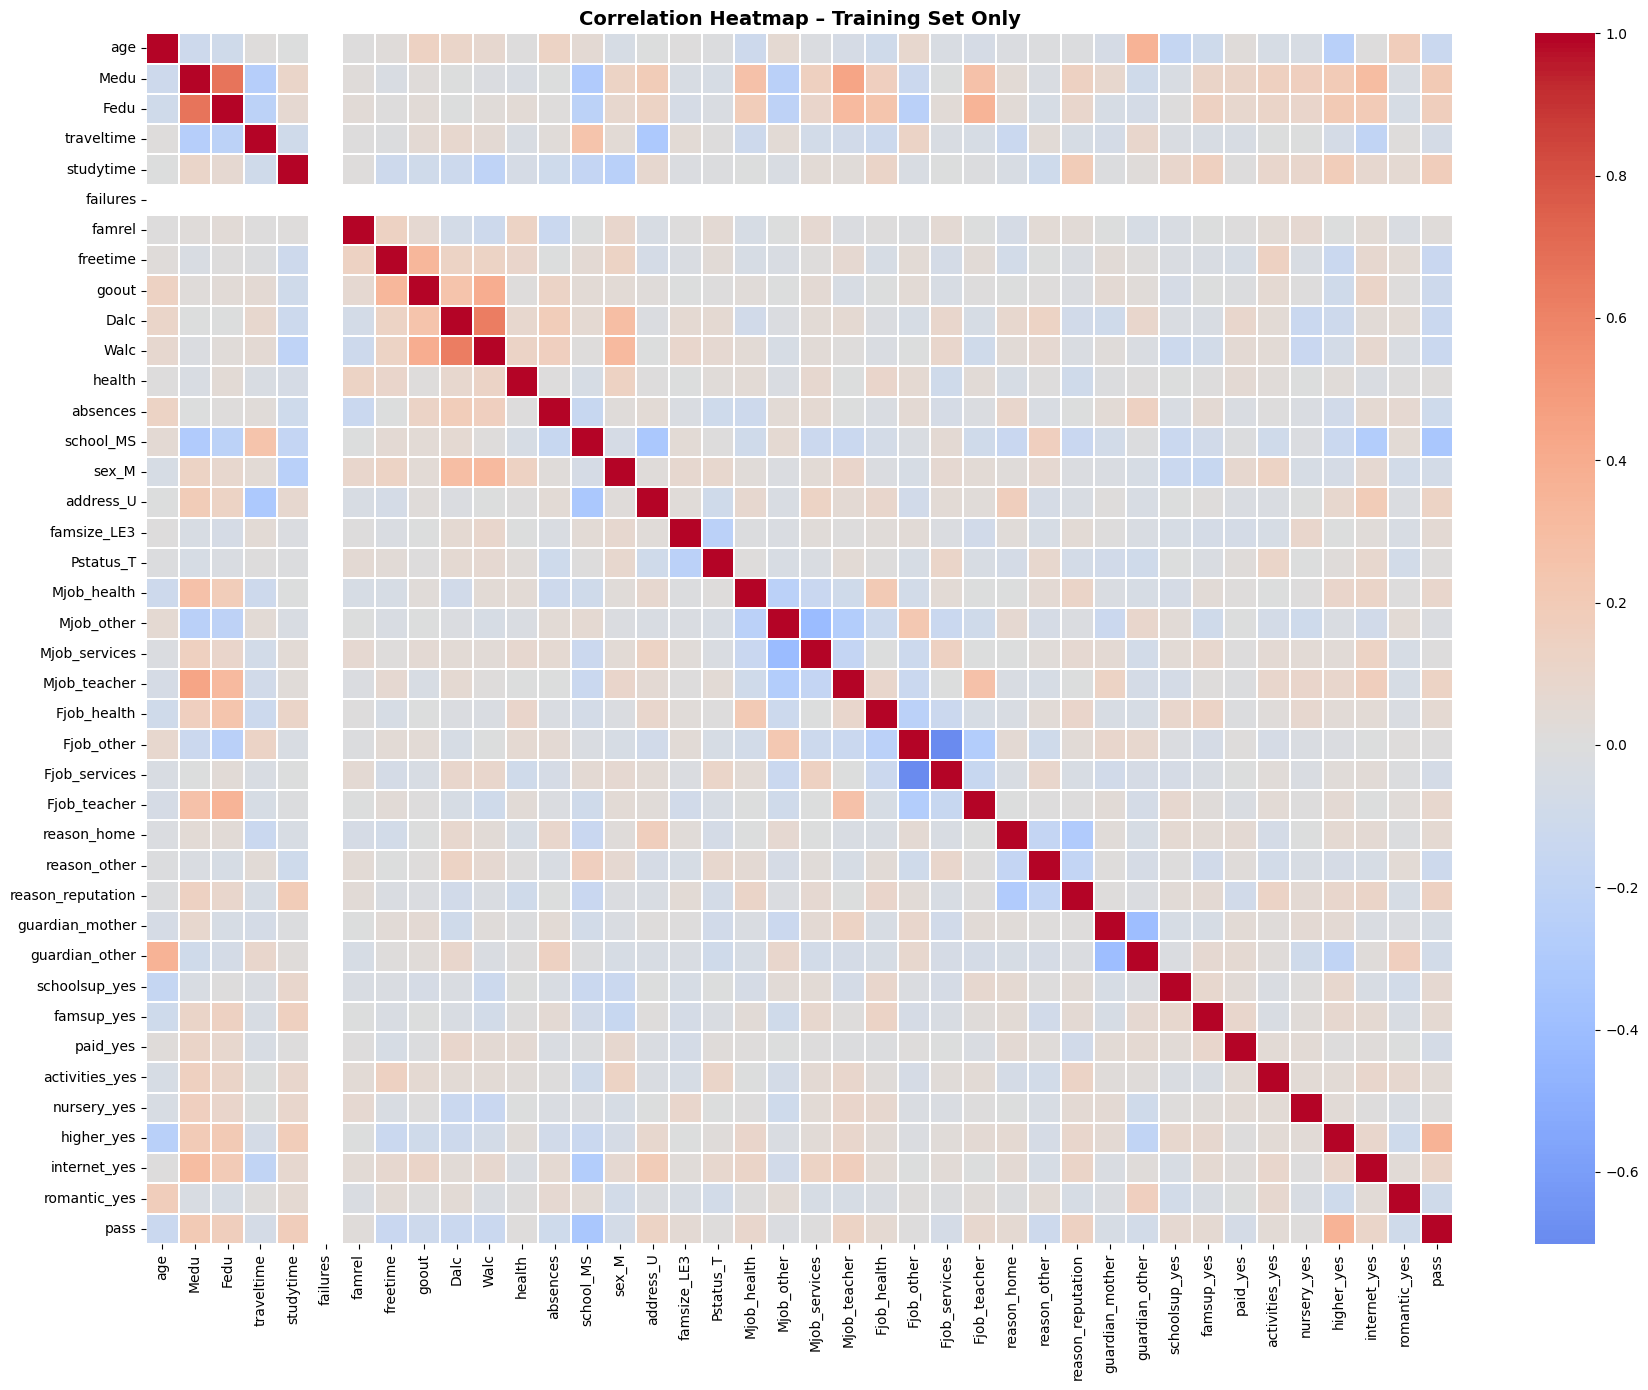

Top 10 features correlated with 'pass' (training set):
higher_yes           0.367077
school_MS            0.331921
Medu                 0.202769
studytime            0.175317
Fedu                 0.165252
reason_reputation    0.147038
freetime             0.142667
Walc                 0.130922
Dalc                 0.130560
age                  0.130490


In [36]:
train_corr = X_train_scaled.copy()
train_corr['pass'] = y_train.values
corr_m = train_corr.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_m, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap – Training Set Only', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_corr_train.png', dpi=150, bbox_inches='tight')
plt.show()

top10 = corr_m['pass'].drop('pass').abs().sort_values(ascending=False).head(10)
print("Top 10 features correlated with 'pass' (training set):")
print(top10.to_string())

## Step 13 – Feature Importance & Interpretation (Task 5)

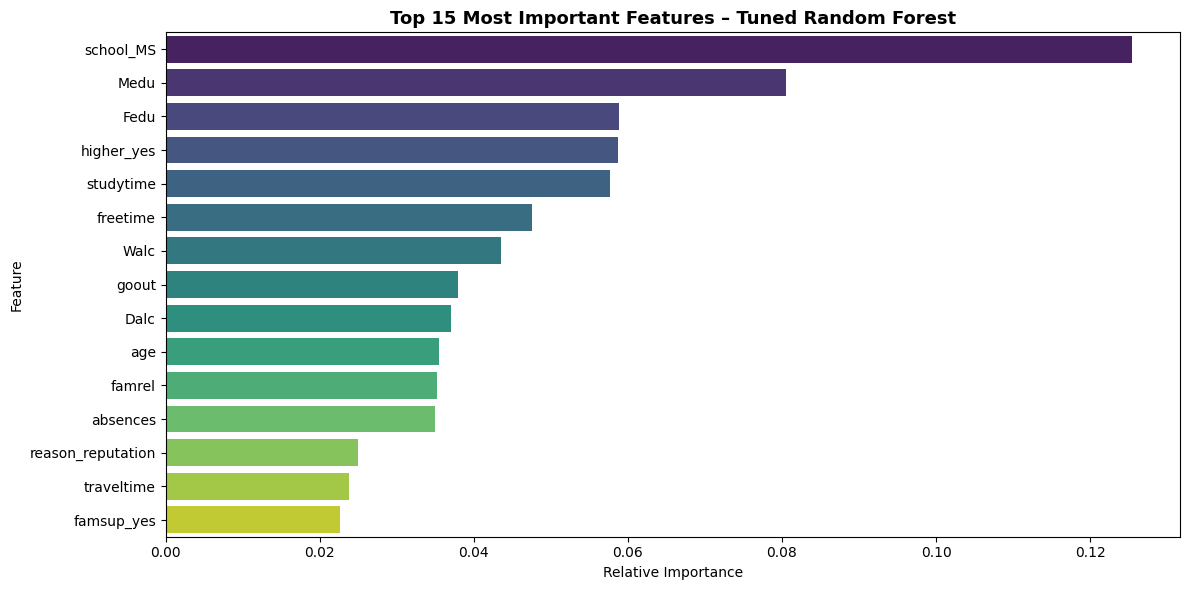

          Feature  Importance
        school_MS    0.125402
             Medu    0.080497
             Fedu    0.058878
       higher_yes    0.058766
        studytime    0.057743
         freetime    0.047599
             Walc    0.043561
            goout    0.037969
             Dalc    0.036981
              age    0.035445
           famrel    0.035224
         absences    0.034980
reason_reputation    0.025015
       traveltime    0.023820
       famsup_yes    0.022605


In [37]:
importances = best_rf.feature_importances_
feat_df = (pd.DataFrame({'Feature': X_train_scaled.columns,
                          'Importance': importances})
             .sort_values('Importance', ascending=False)
             .head(15).reset_index(drop=True))

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features – Tuned Random Forest',
          fontsize=13, fontweight='bold')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(feat_df.to_string(index=False))

## Step 14 – Final Summary & Conclusion (Task 5)

In [38]:
summary = pd.DataFrame([
    {k:v for k,v in r.items() if not k.startswith('_')} for r in proc_results
] + [{'Model':'RF (Tuned)',
      'Accuracy':  accuracy_score(y_test, tuned_pred),
      'Precision': precision_score(y_test, tuned_pred),
      'Recall':    recall_score(y_test, tuned_pred),
      'F1':        f1_score(y_test, tuned_pred),
      'ROC-AUC':   roc_auc_score(y_test, tuned_proba)}]
).set_index('Model').round(4)

print("=== FINAL MODEL PERFORMANCE SUMMARY ===")
print(summary)
print()
best_name = summary['F1'].idxmax()
print(f"Best model by F1: {best_name}")
print()
print("Key conclusions:")
print(f"  1. Top predictive feature: {feat_df.iloc[0]['Feature']}")
print(f"  2. Preprocessing + SMOTE improved avg F1 by "
      f"{np.mean(f1_proc)-np.mean(f1_raw):+.4f}")
print(f"  3. class_weight='balanced' in LR improved Recall for minority class")
print(f"  4. best_depth={best_depth} for DT, best_k={best_k} for KNN "
      f"(from complexity curves)")
print(f"  5. SMOTE was critical – dataset is 84.6% Pass (highly imbalanced)")

=== FINAL MODEL PERFORMANCE SUMMARY ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.6769     0.8864  0.7091  0.7879   0.5759
Decision Tree          0.7615     0.8559  0.8636  0.8597   0.5959
Random Forest          0.7462     0.8407  0.8636  0.8520   0.5955
KNN                    0.6769     0.8617  0.7364  0.7941   0.5432
RF (Tuned)             0.7769     0.8462  0.9000  0.8722   0.6032

Best model by F1: RF (Tuned)

Key conclusions:
  1. Top predictive feature: school_MS
  2. Preprocessing + SMOTE improved avg F1 by -0.0300
  3. class_weight='balanced' in LR improved Recall for minority class
  4. best_depth=5 for DT, best_k=1 for KNN (from complexity curves)
  5. SMOTE was critical – dataset is 84.6% Pass (highly imbalanced)
